# pyCrossTalkeR Example - Human Myelofibrosis

## Running pyCrossTalkeR

First, we need to import the pyCrossTalkeR libraries (tools and plots). Next, we define a named list of either the paths to the Ligand-Receptor interaction tables, or directly dataframe objects for each condition of interest. Please note that it is possible to run pyCrossTalkeR with more than two conditions. Here we load the files from within the package. We can further define a path where we like to save our results (output) and run pyCrossTalkeR with the `analise_LR()` function from the `generate_report.py` file:

In [1]:
from pycrosstalker import tools as cttl
from pycrosstalker import plots as ctpl
import matplotlib.pyplot as plt
import os

In [2]:
paths = {
    'CTR': "CTR_LR.csv",
    'EXP': "EXP_LR.csv"
}
output = "output/"
if not os.path.isdir(output):
    os.mkdir(output)
data = cttl.analise_LR(paths, out_path=output, org="hsa")

Create a Differential Table
Calculating CCI Ranking
Calculating GCI Ranking
Network Analysis Done


Besides passing the paths to the interaction tables and the output folder, we here also define: `out_file` - A suffix for the result reports; `output_fmt` - The file type of the result reports. As result of the successful execution, we receive two pickle objects (LR_data.pkl and LR_data_final.pkl). The LR_data_final.pkl contains all results produced by pyCrossTalkeR. Additionally, the method also returns a lrobject, which can be stored in a variable (here, `data`). It is possible to load the results of the pyCrossTalkeR analysis from the “LR_data_final.pkl" file or from the `data` variable and produce the plots separately. In the following we are going to take a look at different results within the two reports, step by step.

## Single Condition Report

The first report contains the results for each analysed condition considered separately. In our case in each section is a plot for the control condition (CTR) and the disease condition (EXP). There are two main sections in the report. The first one only deals with cell-cell-interactions and the second with cell-gene-interactions, which here means an analysis at the ligand and receptor gene level.

### Cell-Cell-Interaction Analysis Results

The cell-cell-interaction (CCI) graph plots focus on the interactions between the different cell types within the data. We focus on three measures inside this plot:

1. Percentage of interactions indicated by the opacity of the arrows
2. Edge weight (sum of single L-R interaction scores between cell type pairs) indicated by the edge color
3. Pagerank (Node importance) indicated by the node size

After loading the result data from the previous section, we can plot the cell-cell interactions with the `plot_cci()` function. Here we show a plot for each analysed condition:

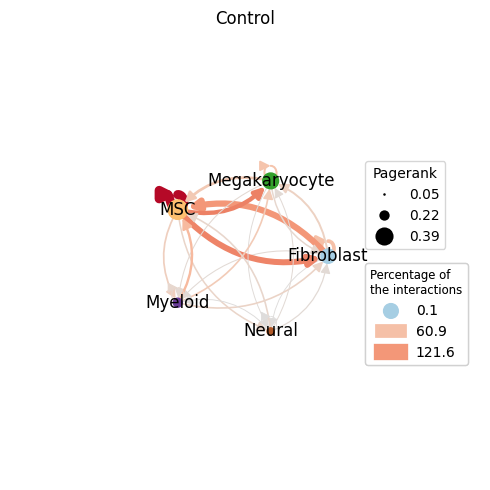

In [3]:
ctpl.plot.plot_cci(graph=data["graphs"]["CTR"],
         colors=data["colors"],
         plt_name='Control',
         coords=data["coords"],
         emax= None,
         leg= False,
         low= 0,
         high= 0, 
         ignore_alpha= False,
         log= False,
         efactor= 6,
         vfactor= 0.03, 
         pg= data["rankings"]["CTR"]["Pagerank"],
         figsize=(5,5))

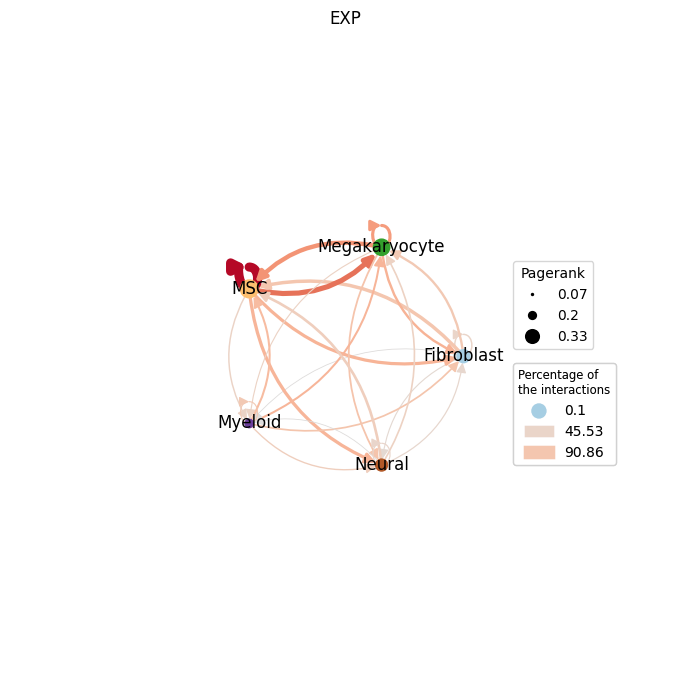

In [4]:

ctpl.plot.plot_cci(graph=data["graphs"]["EXP"],
         colors=data["colors"],
         plt_name='EXP',
         coords=data["coords"],
         emax= None,
         leg= False,
         low= 0,
         high= 0, 
         ignore_alpha= False,
         log= False,
         efactor= 6,
         vfactor= 0.03, 
         pg= data["rankings"]["EXP"]["Pagerank"]
         )

In the control plot we can see that a high proportion of interactions are MSCs talking with themselves as well as MSC and Fibroblasts talking with each other. These interaction have also a higher weight, as can be seen by the edge color. The most important node by pagerank is the MSC node. When analysing the plot of the disease condition, we see again a high proportions of interactions are self-talking MSCs and the most important node by pagerank is again the MSC node. Here the MSC are talking more to Megakaryocytes. To really compare the two conditions we recommend using the Comparative report results.

## Compared Condition Results

pyCrossTalkeR not only analyzes the conditions individually but also calculates the differences in the cell-cell interactions between the conditions. The results of these analyses are presented in the comparative report. In our example we compare the disease (EXP) against the control (CTR) condition.

### Cell-Cell-Interaction analysis results

As before for the single condition results, the first part of the results deal with cell-cell interactions. Here we show again the CCI graph plot, but now for the compared conditions:

/opt/miniconda3/envs/pyCrossTalkeR/lib/python3.13/site-packages/matplotlib/collections.py:996: RuntimeWarning: invalid value encountered in sqrt
/opt/miniconda3/envs/pyCrossTalkeR/lib/python3.13/site-packages/networkx/drawing/nx_pylab.py:707: RuntimeWarning: invalid value encountered in sqrt


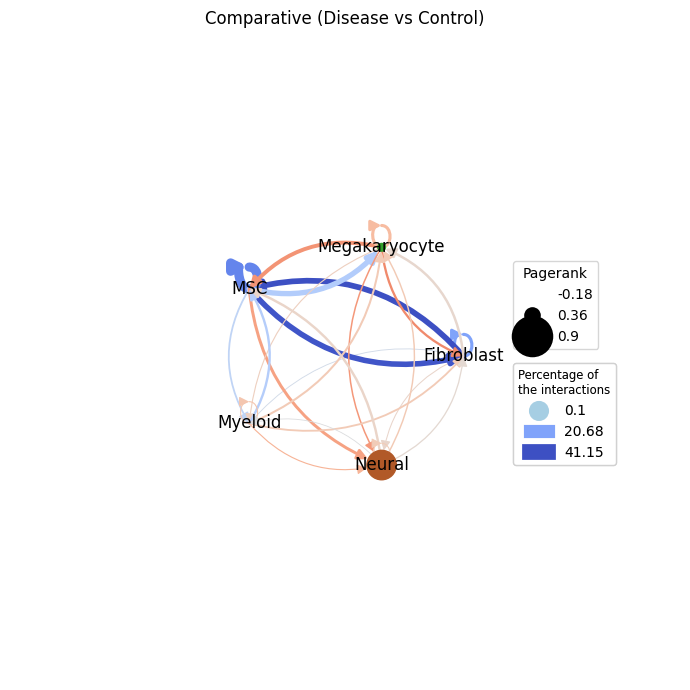

In [5]:
ctpl.plot.plot_cci(graph=data["graphs"]["EXP_x_CTR"],
         colors=data["colors"],
         plt_name='Comparative (Disease vs Control)',
         coords=data["coords"],
         emax= None,
         leg= False,
         low= 0,
         high= 0, 
         ignore_alpha= False,
         log= False,
         efactor= 6,
         vfactor= 0.03, 
         pg= data["rankings"]["EXP_x_CTR"]["Pagerank"]
         )

The main difference from the previous CCI graph plots is that the edge weights can now be not only positive but also negative, as well as the Pagerank values of the nodes. Positive values mean that these interactions between cell types have a higher activity/importance in the EXP condition, while negative values indicate a lower activity/importannce in the EXP condition (higher in CTR). As we can see in the CCI plot above, negative edge weights dominate here, especially in MSC-MSC, MSC-Fibroblast, and Fibroblast-MSC interactions. Thus, we can conclude that these interactions are stronger in the CTR condition. A counterexample of this is the Megakaryocyte-MSC interaction, where we can see from the opaqueness that these interactions only account for a smaller proportion.

In [6]:
data["rankings"]["EXP_x_CTR"]["Pagerank"]

0   -0.172865
1   -0.177139
2    0.061147
3   -0.115831
4    0.896921
Name: Pagerank, dtype: float64

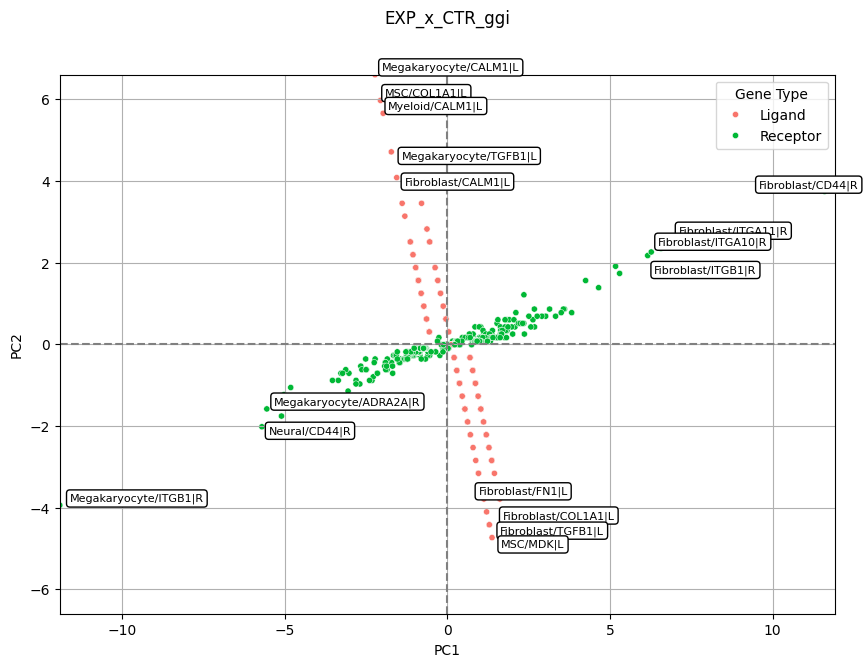

In [7]:
ctpl.plot.plot_pca_LR_comparative(data,pca_table='EXP_x_CTR_ggi',dims=(1,2))